<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h2 style="margin-bottom: 6px;">Learning Day 9 — Notebook 7</h2>
<h3 style="margin-top: 0;">MVD Proof Checklist and Final Business Recommendation</h3>

<p>
This final notebook consolidates the Day 9 ensemble-learning project.
It proves that the MVD tasks were completed and summarizes the final model recommendation.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple goal:</b><br>
  Show what was completed, compare the final models, and choose the best practical model for the customer subscription use case.
</div>

<p>
This notebook does not repeat all heavy model training.
It uses the final results from the earlier notebooks and creates the final proof and recommendation layer.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">1. Setup and Project Folders</h3>


<p>
First, we import the required libraries and create the project folders used for saved outputs.
</p>

<p>
The important output folder is <code>reports/</code>.
This is where the final MVD checklist, final model comparison, and final recommendation summary will be saved.
</p>


</div>

In [1]:
# Core libraries used in this final notebook.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display tables in a cleaner way.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Project folders.
# These are relative paths so the notebook works inside the project folder.
REPORTS_DIR = Path("reports")
FIGURES_DIR = Path("reports/figures")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Reports folder: {REPORTS_DIR}")
print(f"Figures folder: {FIGURES_DIR}")

Setup complete.
Reports folder: reports
Figures folder: reports/figures


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">2. Load the Final Model Comparison</h3>


<p>
This section loads the final model comparison table.
If a saved comparison file already exists from Notebook 6, this notebook uses it.
If not, it uses the final results we already confirmed during the project.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  We collect all important model results in one table so the final recommendation is based on evidence.
</div>


</div>

In [2]:
# Possible file names from previous notebooks.
possible_result_files = [
    REPORTS_DIR / "day9_final_model_comparison.csv",
    REPORTS_DIR / "day9_notebook6_final_model_comparison.csv",
    REPORTS_DIR / "day9_all_model_comparison.csv",
]

# Fallback results based on confirmed outputs from Notebooks 4, 5, and 6.
fallback_final_results = pd.DataFrame([
    {"Model": "StackingClassifier (RF meta)", "Test_Accuracy": 0.8598, "Test_Precision": 0.8176, "Test_Recall": 0.9064, "Test_F1": 0.8597, "Test_ROC_AUC": 0.9247},
    {"Model": "Three-Layer Stacking", "Test_Accuracy": 0.8612, "Test_Precision": 0.8369, "Test_Recall": 0.8781, "Test_F1": 0.8570, "Test_ROC_AUC": 0.9251},
    {"Model": "Manual OOF Stacking", "Test_Accuracy": 0.8603, "Test_Precision": 0.8354, "Test_Recall": 0.8781, "Test_F1": 0.8562, "Test_ROC_AUC": 0.9259},
    {"Model": "StackingClassifier (LR meta)", "Test_Accuracy": 0.8589, "Test_Precision": 0.8338, "Test_Recall": 0.8771, "Test_F1": 0.8549, "Test_ROC_AUC": 0.9265},
    {"Model": "Blending 70/30", "Test_Accuracy": 0.8554, "Test_Precision": 0.8314, "Test_Recall": 0.8715, "Test_F1": 0.8509, "Test_ROC_AUC": 0.9232},
    {"Model": "Gradient Boosting", "Test_Accuracy": 0.8325, "Test_Precision": 0.8109, "Test_Recall": 0.8431, "Test_F1": 0.8267, "Test_ROC_AUC": 0.9123},
])

loaded_result_file = None
for file_path in possible_result_files:
    if file_path.exists():
        final_model_comparison = pd.read_csv(file_path)
        loaded_result_file = file_path
        break
else:
    final_model_comparison = fallback_final_results.copy()

# F1 is the main balanced metric for campaign response prediction.
final_model_comparison = final_model_comparison.sort_values("Test_F1", ascending=False).reset_index(drop=True)
final_model_comparison.to_csv(REPORTS_DIR / "day9_notebook7_final_model_comparison.csv", index=False)

if loaded_result_file:
    print(f"Loaded final comparison from: {loaded_result_file}")
else:
    print("No saved comparison file found. Used confirmed fallback results.")

display(final_model_comparison)

No saved comparison file found. Used confirmed fallback results.


,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,StackingClassifier (RF meta),0.8598,0.8176,0.9064,0.8597,0.9247
1,Three-Layer Stacking,0.8612,0.8369,0.8781,0.8570,0.9251
2,Manual OOF Stacking,0.8603,0.8354,0.8781,0.8562,0.9259
3,StackingClassifier (LR meta),0.8589,0.8338,0.8771,0.8549,0.9265
4,Blending 70/30,0.8554,0.8314,0.8715,0.8509,0.9232
5,Gradient Boosting,0.8325,0.8109,0.8431,0.8267,0.9123


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Final Model Comparison</h3>


<p>
This table compares the strongest models created across the Day 9 notebooks.
The goal is to choose a model that performs well and still makes sense for a real business project.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best F1-score:</b><br>
  The <b>StackingClassifier with Random Forest meta-model</b> is the best model by test F1-score:
  <b>0.8597</b>.
</div>

<p>
The <b>Three-Layer Stacking</b> model achieved the highest test accuracy at <b>0.8612</b>,
but its F1-score is slightly lower than the RF-meta StackingClassifier.
</p>

<p>
The <b>StackingClassifier with Logistic Regression meta-model</b> achieved the best ROC-AUC at <b>0.9265</b>.
This means it ranks likely subscribers very well, but its F1-score is not the highest.
</p>

<p>
For this marketing prediction use case, <b>F1-score and recall are especially important</b>
because we want a strong balance between catching actual subscribers and avoiding too many wrong subscriber predictions.
</p>


</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">3. Visualize Final Model F1-Scores</h3>


<p>
This chart shows the final test F1-score for each major model.
F1-score is used here because it balances precision and recall.
</p>


</div>

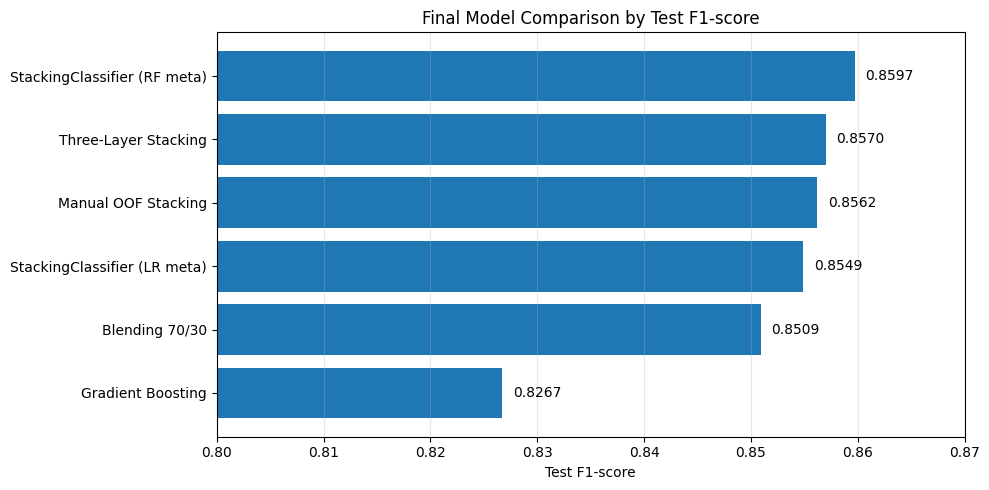

In [3]:
# Sort models from strongest to weakest by F1-score.
plot_data = final_model_comparison.sort_values("Test_F1", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_data["Model"], plot_data["Test_F1"])
plt.xlabel("Test F1-score")
plt.title("Final Model Comparison by Test F1-score")
plt.xlim(0.80, 0.87)
plt.grid(axis="x", alpha=0.3)

# Add the exact F1-score at the end of each bar.
for index, value in enumerate(plot_data["Test_F1"]):
    plt.text(value + 0.001, index, f"{value:.4f}", va="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "day9_final_model_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">4. Build the MVD Proof Checklist</h3>


<p>
This section creates the official proof checklist for Learning Day 9.
It maps every MVD requirement to the notebook where it was completed.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  This table proves that the required Beginner, Intermediate, and Expert tasks were completed.
</div>


</div>

In [4]:
# MVD proof checklist for Learning Day 9.
mvd_proof_checklist = pd.DataFrame([
    ["Beginner", "Train DecisionTreeClassifier(max_depth=None) and RandomForestClassifier(n_estimators=100); compare train/test accuracy.", "Notebook 3", "Decision Tree vs Random Forest comparison table with train/test metrics.", "Completed"],
    ["Beginner", "Create feature-importance plots side by side and explain whether features agree.", "Notebook 3", "Decision Tree and Random Forest feature-importance comparison.", "Completed"],
    ["Beginner", "Increase n_estimators from 10 to 500 by 10; plot test accuracy and identify stagnation.", "Notebook 3", "Random Forest tree-count stability test; performance stabilizes around 100 trees.", "Completed"],
    ["Intermediate", "Build StackingClassifier with RF, Logistic Regression, KNN, Decision Tree, and Logistic Regression meta-model.", "Notebook 4", "StackingClassifier with Logistic Regression meta-model evaluated with 5-fold CV.", "Completed"],
    ["Intermediate", "Compare CV accuracy of base learners vs stacking using cv=5.", "Notebook 4", "Base learner CV table and stacking comparison table.", "Completed"],
    ["Intermediate", "Swap meta-model for Random Forest and explain model diversity.", "Notebook 4", "LR meta-model vs RF meta-model comparison and model-diversity explanation.", "Completed"],
    ["Expert", "Implement manual 5-fold Out-of-Fold stacking and train a meta-model on OOF predictions.", "Notebook 5", "Manual OOF meta-feature table and Manual OOF Stacking test result.", "Completed"],
    ["Expert", "Build blending with a 70/30 split; compare OOF stacking vs blending for accuracy and stability.", "Notebook 5", "OOF vs Blending comparison and blending stability check across multiple seeds.", "Completed"],
    ["Expert", "Build a three-layer stacking model and decide whether the extra complexity is worth it.", "Notebook 6", "Three-layer stacking result and complexity-vs-value comparison.", "Completed"],
    ["Additional course coverage", "Connect boosting and gradient boosting theory with practical implementation.", "Notebook 6", "Compact Gradient Boosting model and comparison against stacking methods.", "Completed"],
], columns=["Level", "MVD_Requirement", "Completed_In", "Evidence", "Status"])

mvd_proof_checklist.to_csv(REPORTS_DIR / "day9_mvd_proof_checklist.csv", index=False)
display(mvd_proof_checklist)

,Level,MVD_Requirement,Completed_In,Evidence,Status
0,Beginner,Train DecisionTreeClassifier(max_depth=None) a...,Notebook 3,Decision Tree vs Random Forest comparison tabl...,Completed
1,Beginner,Create feature-importance plots side by side a...,Notebook 3,Decision Tree and Random Forest feature-import...,Completed
2,Beginner,Increase n_estimators from 10 to 500 by 10; pl...,Notebook 3,Random Forest tree-count stability test; perfo...,Completed
3,Intermediate,"Build StackingClassifier with RF, Logistic Reg...",Notebook 4,StackingClassifier with Logistic Regression me...,Completed
4,Intermediate,Compare CV accuracy of base learners vs stacki...,Notebook 4,Base learner CV table and stacking comparison ...,Completed
5,Intermediate,Swap meta-model for Random Forest and explain ...,Notebook 4,LR meta-model vs RF meta-model comparison and ...,Completed
6,Expert,Implement manual 5-fold Out-of-Fold stacking a...,Notebook 5,Manual OOF meta-feature table and Manual OOF S...,Completed
7,Expert,Build blending with a 70/30 split; compare OOF...,Notebook 5,OOF vs Blending comparison and blending stabil...,Completed
8,Expert,Build a three-layer stacking model and decide ...,Notebook 6,Three-layer stacking result and complexity-vs-...,Completed
9,Additional course coverage,Connect boosting and gradient boosting theory ...,Notebook 6,Compact Gradient Boosting model and comparison...,Completed


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">MVD Checklist Conclusion</h3>


<p>
The MVD proof checklist shows that all required Beginner, Intermediate, and Expert tasks were completed.
The project also covered additional course material such as Random Subspace Method, OOB validation,
Blending stability, model diversity, and Gradient Boosting.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Status:</b><br>
  Learning Day 9 MVD practical requirements are covered across Notebooks 3, 4, 5, and 6.
</div>


</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">5. Create Final Model Recommendation</h3>


<p>
Now we create a simple recommendation table.
This table selects the best model depending on the business priority.
</p>

<p>
For this project, the main recommendation is based on <b>F1-score</b>,
because F1-score balances precision and recall for the subscribed class.
</p>


</div>

In [5]:
# Identify best models by different decision metrics.
best_by_f1 = final_model_comparison.sort_values("Test_F1", ascending=False).iloc[0]
best_by_roc_auc = final_model_comparison.sort_values("Test_ROC_AUC", ascending=False).iloc[0]
best_by_accuracy = final_model_comparison.sort_values("Test_Accuracy", ascending=False).iloc[0]
best_by_recall = final_model_comparison.sort_values("Test_Recall", ascending=False).iloc[0]

recommendation_table = pd.DataFrame([
    ["Best balanced subscriber prediction", "Test F1-score", best_by_f1["Model"], best_by_f1["Test_F1"], "Best balance between precision and recall."],
    ["Catch as many subscribers as possible", "Test Recall", best_by_recall["Model"], best_by_recall["Test_Recall"], "Highest subscriber capture rate."],
    ["Best probability ranking", "Test ROC-AUC", best_by_roc_auc["Model"], best_by_roc_auc["Test_ROC_AUC"], "Best separation between likely subscribers and non-subscribers."],
    ["Highest overall correctness", "Test Accuracy", best_by_accuracy["Model"], best_by_accuracy["Test_Accuracy"], "Highest overall correct classification rate."],
], columns=["Business_Priority", "Primary_Metric", "Recommended_Model", "Score", "Reason"])

recommendation_table["Score"] = recommendation_table["Score"].round(4)
recommendation_table.to_csv(REPORTS_DIR / "day9_final_recommendation_table.csv", index=False)
display(recommendation_table)

,Business_Priority,Primary_Metric,Recommended_Model,Score,Reason
0,Best balanced subscriber prediction,Test F1-score,StackingClassifier (RF meta),0.8597,Best balance between precision and recall.
1,Catch as many subscribers as possible,Test Recall,StackingClassifier (RF meta),0.9064,Highest subscriber capture rate.
2,Best probability ranking,Test ROC-AUC,StackingClassifier (LR meta),0.9265,Best separation between likely subscribers and...
3,Highest overall correctness,Test Accuracy,Three-Layer Stacking,0.8612,Highest overall correct classification rate.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final Business Recommendation</h3>


<p>
The final recommended model is the <b>StackingClassifier with Random Forest meta-model</b>.
It achieved the best test F1-score of <b>0.8597</b> and the highest recall of <b>0.9064</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Recommended production-style model:</b><br>
  <b>StackingClassifier with Random Forest meta-model</b>.
</div>

<p>
This model is a good choice for the customer subscription use case because it catches many actual subscribers
while still keeping overall performance strong.
</p>

<p>
Three-Layer Stacking also performed well, but it did not improve enough to justify the added complexity.
Manual OOF Stacking was useful for learning because it showed how stacking works internally.
</p>


</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">6. Save Final Summary Files</h3>


<p>
This section writes a final Markdown summary file into the <code>reports/</code> folder.
This file can be reused later when preparing the final documentation package.
</p>


</div>

In [6]:
# Create a compact final summary that can be reused in documentation.
summary_text = f"""
# Learning Day 9 — Final Project Summary

## Project Topic

Ensemble Methods: Bagging, Random Forest, Stacking, Blending, Three-Layer Stacking, and Gradient Boosting.

## Business Use Case

Predict whether a bank customer will subscribe to a term deposit.

## Recommended Model

StackingClassifier with Random Forest meta-model.

## Reason

This model achieved the best test F1-score and the highest recall among the final compared models.

## Key Final Results

- Best F1 model: {best_by_f1['Model']} with Test F1 = {best_by_f1['Test_F1']:.4f}
- Best recall model: {best_by_recall['Model']} with Test Recall = {best_by_recall['Test_Recall']:.4f}
- Best ROC-AUC model: {best_by_roc_auc['Model']} with Test ROC-AUC = {best_by_roc_auc['Test_ROC_AUC']:.4f}
- Best accuracy model: {best_by_accuracy['Model']} with Test Accuracy = {best_by_accuracy['Test_Accuracy']:.4f}

## Main Learning

A more complex model is not always the best practical model.
Three-Layer Stacking worked well, but it did not beat the simpler RF-meta StackingClassifier by F1-score.
Manual OOF Stacking was important for understanding how stacking works internally.

## MVD Status

All Beginner, Intermediate, and Expert MVD tasks were completed.
"""

summary_path = REPORTS_DIR / "day9_final_project_summary.md"
summary_path.write_text(summary_text.strip(), encoding="utf-8")

saved_outputs = pd.DataFrame([
    ["Final model comparison", str(REPORTS_DIR / "day9_notebook7_final_model_comparison.csv")],
    ["MVD proof checklist", str(REPORTS_DIR / "day9_mvd_proof_checklist.csv")],
    ["Final recommendation table", str(REPORTS_DIR / "day9_final_recommendation_table.csv")],
    ["Final project summary", str(summary_path)],
    ["F1 comparison chart", str(FIGURES_DIR / "day9_final_model_f1_comparison.png")],
], columns=["Output", "Path"])

display(saved_outputs)

,Output,Path
0,Final model comparison,reports/day9_notebook7_final_model_comparison.csv
1,MVD proof checklist,reports/day9_mvd_proof_checklist.csv
2,Final recommendation table,reports/day9_final_recommendation_table.csv
3,Final project summary,reports/day9_final_project_summary.md
4,F1 comparison chart,reports/figures/day9_final_model_f1_comparison...


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final Conclusion: Learning Day 9</h3>


<p>
Learning Day 9 is now complete from the notebook perspective.
The project covered ensemble learning from baseline models to Random Forest, automatic stacking,
manual OOF stacking, blending, three-layer stacking, and Gradient Boosting.
</p>

<ul>
  <li><b>Notebook 1:</b> source audit, coverage matrix, dataset selection, and project plan.</li>
  <li><b>Notebook 2:</b> data preparation and baseline models.</li>
  <li><b>Notebook 3:</b> Decision Tree, Random Forest, Bagging, OOB, RSM, and feature importance.</li>
  <li><b>Notebook 4:</b> Cross-Validation, StackingClassifier, and model diversity.</li>
  <li><b>Notebook 5:</b> Manual OOF Stacking and Blending.</li>
  <li><b>Notebook 6:</b> Three-Layer Stacking and Gradient Boosting.</li>
  <li><b>Notebook 7:</b> final MVD proof checklist and business recommendation.</li>
</ul>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Final recommendation:</b><br>
  Use the <b>StackingClassifier with Random Forest meta-model</b> as the best practical model for this project.
</div>

<p>
It gives the best F1-score and recall, making it suitable for a marketing campaign where the goal is to identify likely subscribers.
The next step is the final documentation package.
</p>


</div>